In [1]:
!pip install py-feat

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
INFO: pip is looking at multiple versions of nltools to determine which version is compatible with other requirements. This could take a while.
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
     ---------------------------------------- 0.0/13.5 MB ? eta -:--:--
     --- ------------------------------------ 1.0/13.5 MB 7.0 MB/s eta 0:00:02
     ------------ --------------------------- 4.2/13.5 MB 14.6 MB/s eta 0:00:01
     ------------------ --------------------- 6.3/13.5 MB 11.4 MB/s eta 0:00:01
     --------------------- ------------------ 7.3/13.5 MB 10.8 MB/s eta 0:00:01
     ----------------------------- --------- 10.2/13.5 MB 10

  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [10 lines of output]
      + meson setup C:\Users\ddonz\AppData\Local\Temp\pip-install-ta13ts8h\contourpy_6609cecbe7cd4b9f8780cd1bbf21d12e C:\Users\ddonz\AppData\Local\Temp\pip-install-ta13ts8h\contourpy_6609cecbe7cd4b9f8780cd1bbf21d12e\.mesonpy-aj0fxo9h -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --vsenv --native-file=C:\Users\ddonz\AppData\Local\Temp\pip-install-ta13ts8h\contourpy_6609cecbe7cd4b9f8780cd1bbf21d12e\.mesonpy-aj0fxo9h\meson-python-native-file.ini
      The Meson build system
      Version: 1.10.1
      Source dir: C:\Users\ddonz\AppData\Local\Temp\pip-install-ta13ts8h\contourpy_6609cecbe7cd4b9f8780cd1bbf21d12e
      Build dir: C:\Users\ddonz\AppData\Local\Temp\pip-install-ta13ts8h\contourpy_6609cecbe7cd4b9f8780cd1bbf21d12e\.mesonpy-aj0fxo9h
      Build type: native build
      
      ..\meson.build:1:0: ERROR: Could not find C:\Prog

In [1]:
import os

#DIRECTORY_VARIABLES NEED TO CHANGE TO YOUR CORRECT DIRECTORIES
pasta_diretorio = r'\ABAW\data'

split_dir = os.path.join(pasta_diretorio, 'split')
faces_dir = os.path.join(pasta_diretorio, 'cropped-aligned-faces')
# Ver estrutura
videos = os.listdir(faces_dir)
print(f"Total de pastas: {len(videos)}")
print(f"Primeiras 5: {videos[:5]}")

# Ver dentro de uma pasta
first_video = videos[0]
frames = os.listdir(os.path.join(faces_dir, first_video))
print(f"\nDentro de '{first_video}':")
print(f"  Total frames: {len(frames)}")
print(f"  Primeiros 5: {frames[:5]}")

Total de pastas: 1
Primeiras 5: ['Videos']

Dentro de 'Videos':
  Total frames: 300
  Primeiros 5: ['82553', '82554', '82555', '82557', '82563']


In [2]:
import os

faces_dir = os.path.join(pasta_diretorio, 'cropped-aligned-faces', 'Videos')

# Nível 1: participantes
participants = os.listdir(faces_dir)
print(f"Total participantes: {len(participants)}")
print(f"Primeiros 5: {participants[:5]}")

# Nível 2: dentro de um participante
first_p = participants[0]
level2 = os.listdir(os.path.join(faces_dir, first_p))
print(f"\nDentro de '{first_p}': {level2}")

# Nível 3: dentro da visita
level3_path = os.path.join(faces_dir, first_p, level2[0])
level3 = os.listdir(level3_path)
print(f"\nDentro de '{level2[0]}': {level3[:3]}")

# Nível 4: dentro de um vídeo
level4_path = os.path.join(level3_path, level3[0])
frames = os.listdir(level4_path)
print(f"\nDentro de '{level3[0]}':")
print(f"  Total frames: {len(frames)}")
print(f"  Primeiros 5: {frames[:5]}")

Total participantes: 300
Primeiros 5: ['82553', '82554', '82555', '82557', '82563']

Dentro de '82553': ['Visite_1']

Dentro de 'Visite_1': ['82553_Question_1_2024-08-22_12-11-55_Video.mp4', '82553_Question_2_2024-08-22_12-17-23_Video.mp4', '82553_Question_3_2024-08-22_12-19-41_Video.mp4']

Dentro de '82553_Question_1_2024-08-22_12-11-55_Video.mp4':
  Total frames: 418
  Primeiros 5: ['frame-0.jpg', 'frame-1.jpg', 'frame-10.jpg', 'frame-100.jpg', 'frame-101.jpg']


In [3]:
from feat import Detector
from PIL import Image
import numpy as np
import os

# Inicializar detector - só AU, sem detecção de face (já tão cropadas)
detector = Detector(face_model='retinaface', au_model='xgb')

# Testar com um frame
test_frame_path = os.path.join(
    pasta_diretorio, 'cropped-aligned-faces', 'Videos',
    '82553', 'Visite_1',
    '82553_Question_1_2024-08-22_12-11-55_Video.mp4',
    'frame-0.jpg'
)

result = detector.detect_image(test_frame_path)
print(f"Colunas AU: {[c for c in result.columns if c.startswith('AU')]}")
print(f"\nValores do frame-0:")
au_cols = [c for c in result.columns if c.startswith('AU')]
print(result[au_cols].values)

100%|██████████| 1/1 [00:02<00:00,  2.38s/it]


Colunas AU: ['AU01', 'AU02', 'AU04', 'AU05', 'AU06', 'AU07', 'AU09', 'AU10', 'AU11', 'AU12', 'AU14', 'AU15', 'AU17', 'AU20', 'AU23', 'AU24', 'AU25', 'AU26', 'AU28', 'AU43']

Valores do frame-0:
[[5.1125270e-01 2.3139264e-01 5.4142994e-01 2.6082155e-01 2.7005497e-01
  0.0000000e+00 4.1562116e-01 7.1521709e-04 0.0000000e+00 6.0490739e-02
  2.3513387e-01 7.7243567e-01 5.8803850e-01 0.0000000e+00 2.7639347e-01
  3.8458866e-01 1.1935657e-01 1.9703496e-01 1.0477802e-01 3.4833813e-01]]


In [4]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import re

faces_base = os.path.join(pasta_diretorio, 'cropped-aligned-faces', 'Videos')
output_dir = os.path.join(pasta_diretorio, 'au_features')
os.makedirs(output_dir, exist_ok=True)

au_cols = ['AU01', 'AU02', 'AU04', 'AU05', 'AU06', 'AU07', 'AU09', 'AU10',
           'AU11', 'AU12', 'AU14', 'AU15', 'AU17', 'AU20', 'AU23', 'AU24',
           'AU25', 'AU26', 'AU28', 'AU43']

# Listar todos os vídeos
all_videos = []
for participant in os.listdir(faces_base):
    p_path = os.path.join(faces_base, participant, 'Visite_1')
    if os.path.isdir(p_path):
        for video in os.listdir(p_path):
            v_path = os.path.join(p_path, video)
            if os.path.isdir(v_path):
                all_videos.append((participant, video, v_path))

print(f"Total vídeos a processar: {len(all_videos)}")

# Estimar tempo
print(f"Estimativa: ~1.7s por frame × ~642 frames média = ~18min por vídeo")
print(f"Total estimado: ~{len(all_videos) * 18 / 60:.0f} horas")

Total vídeos a processar: 1427
Estimativa: ~1.7s por frame × ~642 frames média = ~18min por vídeo
Total estimado: ~428 horas


In [10]:
import yaml

# Carregar metadata pra verificar consentimento de publicação
with open(os.path.join(pasta_diretorio, 'meta_data.yml'), 'r', encoding='utf-8') as f:
    meta = yaml.safe_load(f)

# Ver estrutura do metadata
first_key = list(meta.keys())[0]
print(f"Exemplo metadata: {first_key}")
print(meta[first_key])

Exemplo metadata: 82553
{'Age': 51, 'Age range': '45 - 54 years', 'Birth country': 'Canada', 'Canada province': 'Ontario (ON)', 'Ethnicity': 'East Asian (Chinese, Korean, Japanese, and/or Taiwanese descent)', 'Ethnicity simplified': 'Asian', 'Gender': 'Male', 'Is student': 'No', 'Use in challenges': 'Yes', 'Use in publications': 'Yes'}


In [11]:
# Encontrar participantes que:
# 1. Permitem uso em publicações
# 2. Têm 7 vídeos
# 3. Um com A/H e outro sem A/H

# Carregar labels
df = pd.read_csv(os.path.join(pasta_diretorio, 'bah-video.csv'))
df['participant_id'] = df['video-path'].str.split('/').str[1]

for pid, group in df.groupby('participant_id'):
    if len(group) == 7:
        has_ah = group['label'].sum()
        pid_int = int(pid)

        # Verificar se permite publicação
        if pid in meta or pid_int in meta:
            m = meta.get(pid, meta.get(pid_int, {}))
            use_pub = m.get('Use in publications', None)

            if has_ah > 0 and has_ah < 7 and use_pub:
                print(f"COM A/H - Participante {pid}: {has_ah}/7 vídeos A/H | Publicação: {use_pub}")
                print(f"  Labels: {group['label'].tolist()}")
                break

for pid, group in df.groupby('participant_id'):
    if len(group) == 7:
        has_ah = group['label'].sum()
        pid_int = int(pid)

        if pid in meta or pid_int in meta:
            m = meta.get(pid, meta.get(pid_int, {}))
            use_pub = m.get('Use in publications', None)

            if has_ah == 0 and use_pub:
                print(f"SEM A/H - Participante {pid}: 0/7 vídeos A/H | Publicação: {use_pub}")
                print(f"  Labels: {group['label'].tolist()}")
                break

COM A/H - Participante 82553: 5/7 vídeos A/H | Publicação: Yes
  Labels: [0, 1, 1, 1, 0, 1, 1]
SEM A/H - Participante 82609: 0/7 vídeos A/H | Publicação: Yes
  Labels: [0, 0, 0, 0, 0, 0, 0]


In [12]:
from tqdm import tqdm
import re

target_participants = ['82553', '82609']

au_data = {}

for pid in target_participants:
    p_path = os.path.join(faces_base, pid, 'Visite_1')
    videos = sorted(os.listdir(p_path))
    au_data[pid] = {}

    for video_name in videos:
        v_path = os.path.join(p_path, video_name)
        frames = os.listdir(v_path)

        # Ordenar frames numericamente
        def frame_num(f):
            return int(re.search(r'frame-(\d+)', f).group(1))
        frames = sorted(frames, key=frame_num)

        print(f"\nProcessando {pid} - {video_name} ({len(frames)} frames)")

        au_values = []
        for frame_file in tqdm(frames):
            frame_path = os.path.join(v_path, frame_file)
            try:
                result = detector.detect_image(frame_path)
                aus = result[au_cols].values[0]
                au_values.append(aus)
            except:
                au_values.append(np.zeros(20))

        au_data[pid][video_name] = np.array(au_values)
        print(f"  Shape: {au_data[pid][video_name].shape}")

print("\nExtração completa!")


Processando 82553 - 82553_Question_1_2024-08-22_12-11-55_Video.mp4 (418 frames)


100%|██████████| 418/418 [10:43<00:00,  1.54s/it]


  Shape: (418, 20)

Processando 82553 - 82553_Question_2_2024-08-22_12-17-23_Video.mp4 (421 frames)


100%|██████████| 421/421 [09:37<00:00,  1.37s/it]


  Shape: (421, 20)

Processando 82553 - 82553_Question_3_2024-08-22_12-19-41_Video.mp4 (348 frames)


...

  Shape: (232, 20)

Processando 82609 - 82609_Question_6_2024-11-02_17-54-52_Video.mp4 (121 frames)


100%|██████████| 121/121 [03:01<00:00,  1.50s/it]


  Shape: (121, 20)

Processando 82609 - 82609_Question_7_2024-11-02_17-55-31_Video.mp4 (328 frames)


  0%|          | 0/1 [00:00<?, ?it/s]WARNING:root:Warning: NO FACE is detected

100%|██████████| 328/328 [08:11<00:00,  1.50s/it]

  Shape: (328, 20)

Extração completa!


In [13]:
# Verificar o que temos
for pid in target_participants:
    print(f"\n=== Participante {pid} ===")
    for video_name, aus in au_data[pid].items():
        # Pegar label
        row = df[df['video-path'].str.contains(video_name.replace('.mp4', ''))]
        label = row['label'].values[0] if len(row) > 0 else '?'
        print(f"  {video_name[:40]}... | Shape: {aus.shape} | Label: {label}")


=== Participante 82553 ===
  82553_Question_1_2024-08-22_12-11-55_Vid... | Shape: (418, 20) | Label: 1
  82553_Question_2_2024-08-22_12-17-23_Vid... | Shape: (421, 20) | Label: 1
  82553_Question_3_2024-08-22_12-19-41_Vid... | Shape: (348, 20) | Label: 0
  82553_Question_4_2024-08-22_12-18-20_Vid... | Shape: (368, 20) | Label: 1
  82553_Question_5_2024-08-22_12-12-54_Vid... | Shape: (248, 20) | Label: 0
  82553_Question_6_2024-08-22_12-15-47_Vid... | Shape: (475, 20) | Label: 1
  82553_Question_7_2024-08-22_12-14-07_Vid... | Shape: (349, 20) | Label: 1

=== Participante 82609 ===
  82609_Question_1_2024-11-02_17-54-25_Vid... | Shape: (207, 20) | Label: 0
  82609_Question_2_2024-11-02_17-56-32_Vid... | Shape: (264, 20) | Label: 0
  82609_Question_3_2024-11-02_17-56-15_Vid... | Shape: (334, 20) | Label: 0
  82609_Question_4_2024-11-02_17-55-52_Vid... | Shape: (273, 20) | Label: 0
  82609_Question_5_2024-11-02_17-55-09_Vid... | Shape: (232, 20) | Label: 0
  82609_Question_6_2024-11-02_17

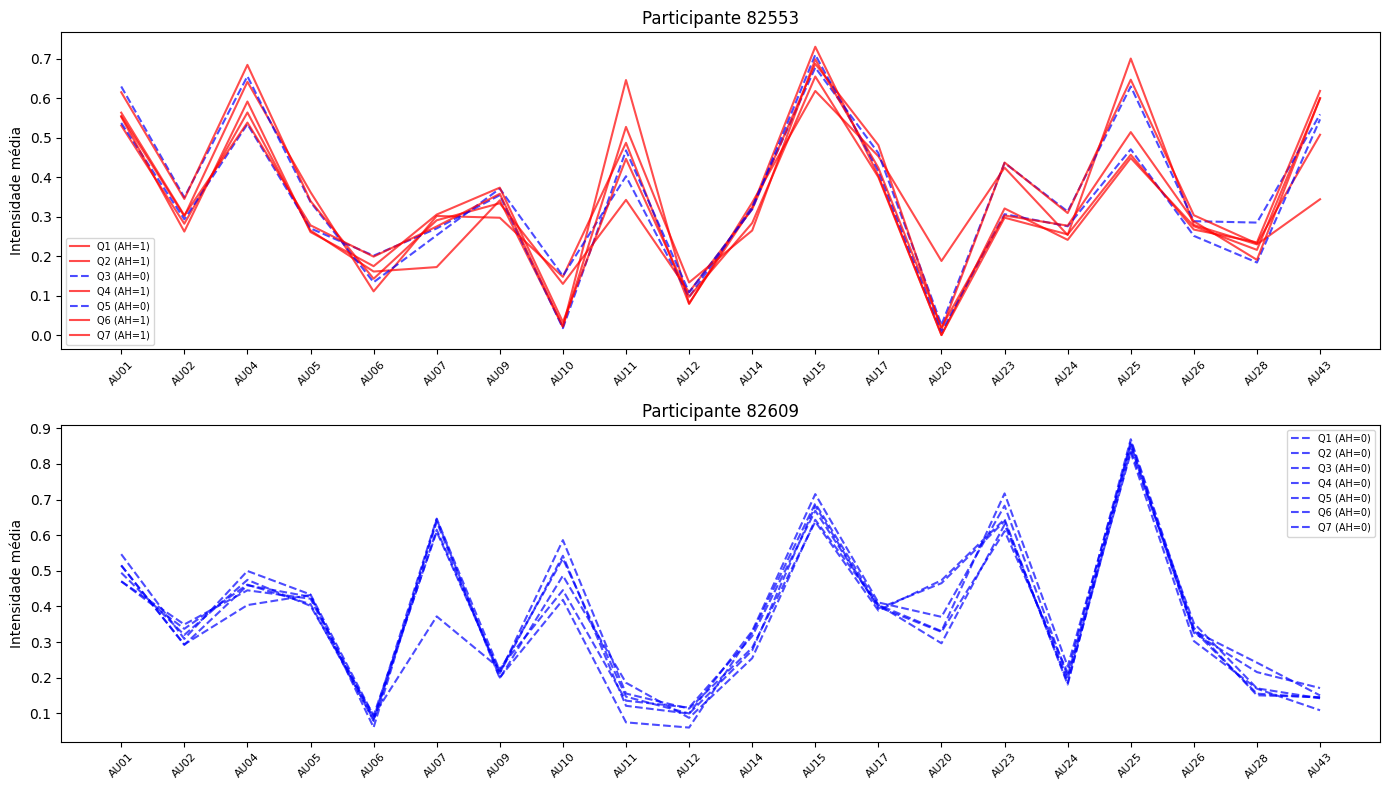

In [14]:
# Análise 1: Média de cada AU por vídeo - comparar A/H vs não A/H
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, pid in zip(axes, target_participants):
    for video_name, aus in au_data[pid].items():
        row = df[df['video-path'].str.contains(video_name.replace('.mp4', ''))]
        label = row['label'].values[0] if len(row) > 0 else 0
        color = 'red' if label == 1 else 'blue'
        style = '-' if label == 1 else '--'

        mean_aus = aus.mean(axis=0)
        ax.plot(mean_aus, color=color, linestyle=style, alpha=0.7,
                label=f"Q{video_name.split('Question_')[1][0]} (AH={label})")

    ax.set_xticks(range(20))
    ax.set_xticklabels(au_cols, rotation=45, fontsize=8)
    ax.set_ylabel('Intensidade média')
    ax.set_title(f'Participante {pid}')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

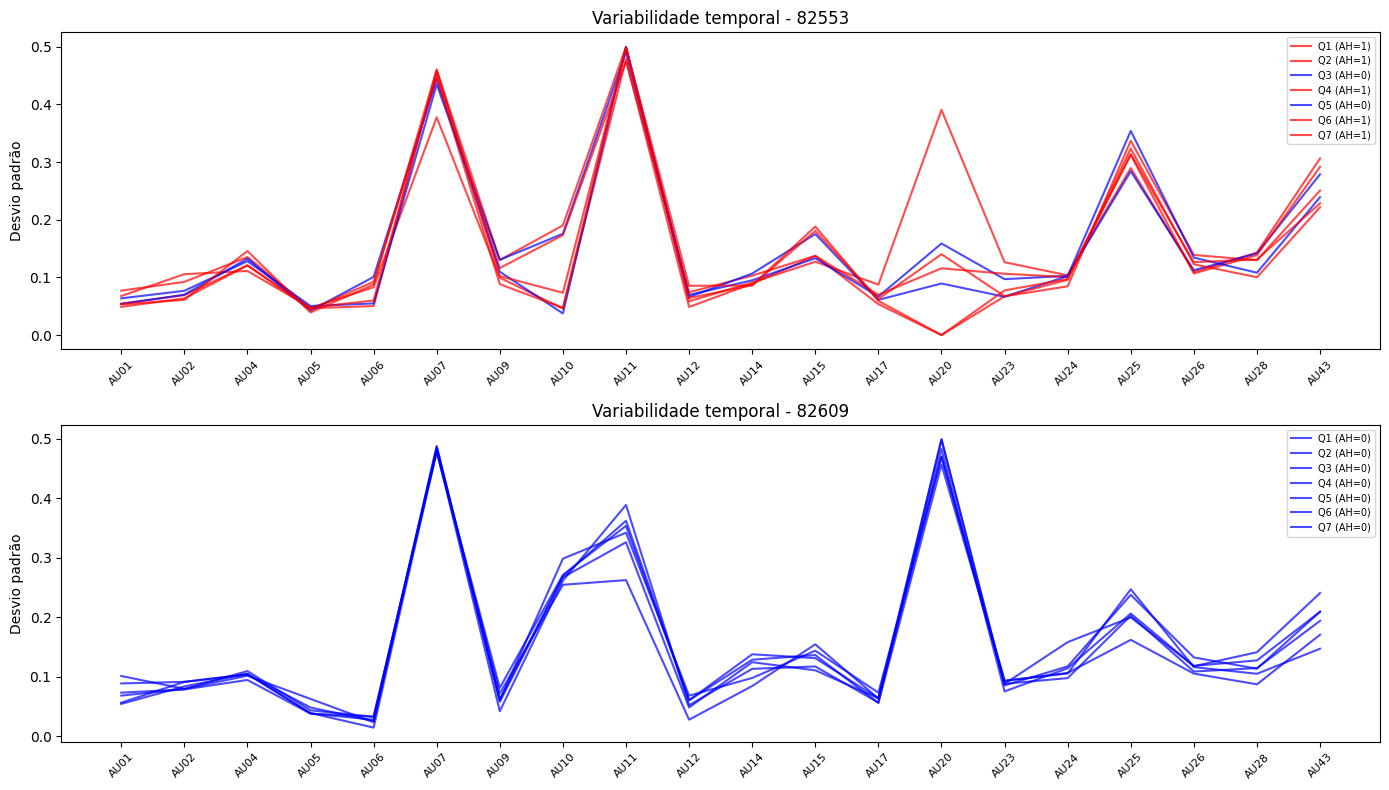

In [17]:
# Análise 2: Variabilidade temporal (std) das AUs - A/H deve ter mais flutuação
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, pid in zip(axes, target_participants):
    for video_name, aus in au_data[pid].items():
        row = df[df['video-path'].str.contains(video_name.replace('.mp4', ''))]
        label = row['label'].values[0] if len(row) > 0 else 0
        color = 'red' if label == 1 else 'blue'

        std_aus = aus.astype(np.float64).std(axis=0)
        ax.plot(std_aus, color=color, alpha=0.7,
                label=f"Q{video_name.split('Question_')[1][0]} (AH={label})")

    ax.set_xticks(range(20))
    ax.set_xticklabels(au_cols, rotation=45, fontsize=8)
    ax.set_ylabel('Desvio padrão')
    ax.set_title(f'Variabilidade temporal - {pid}')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

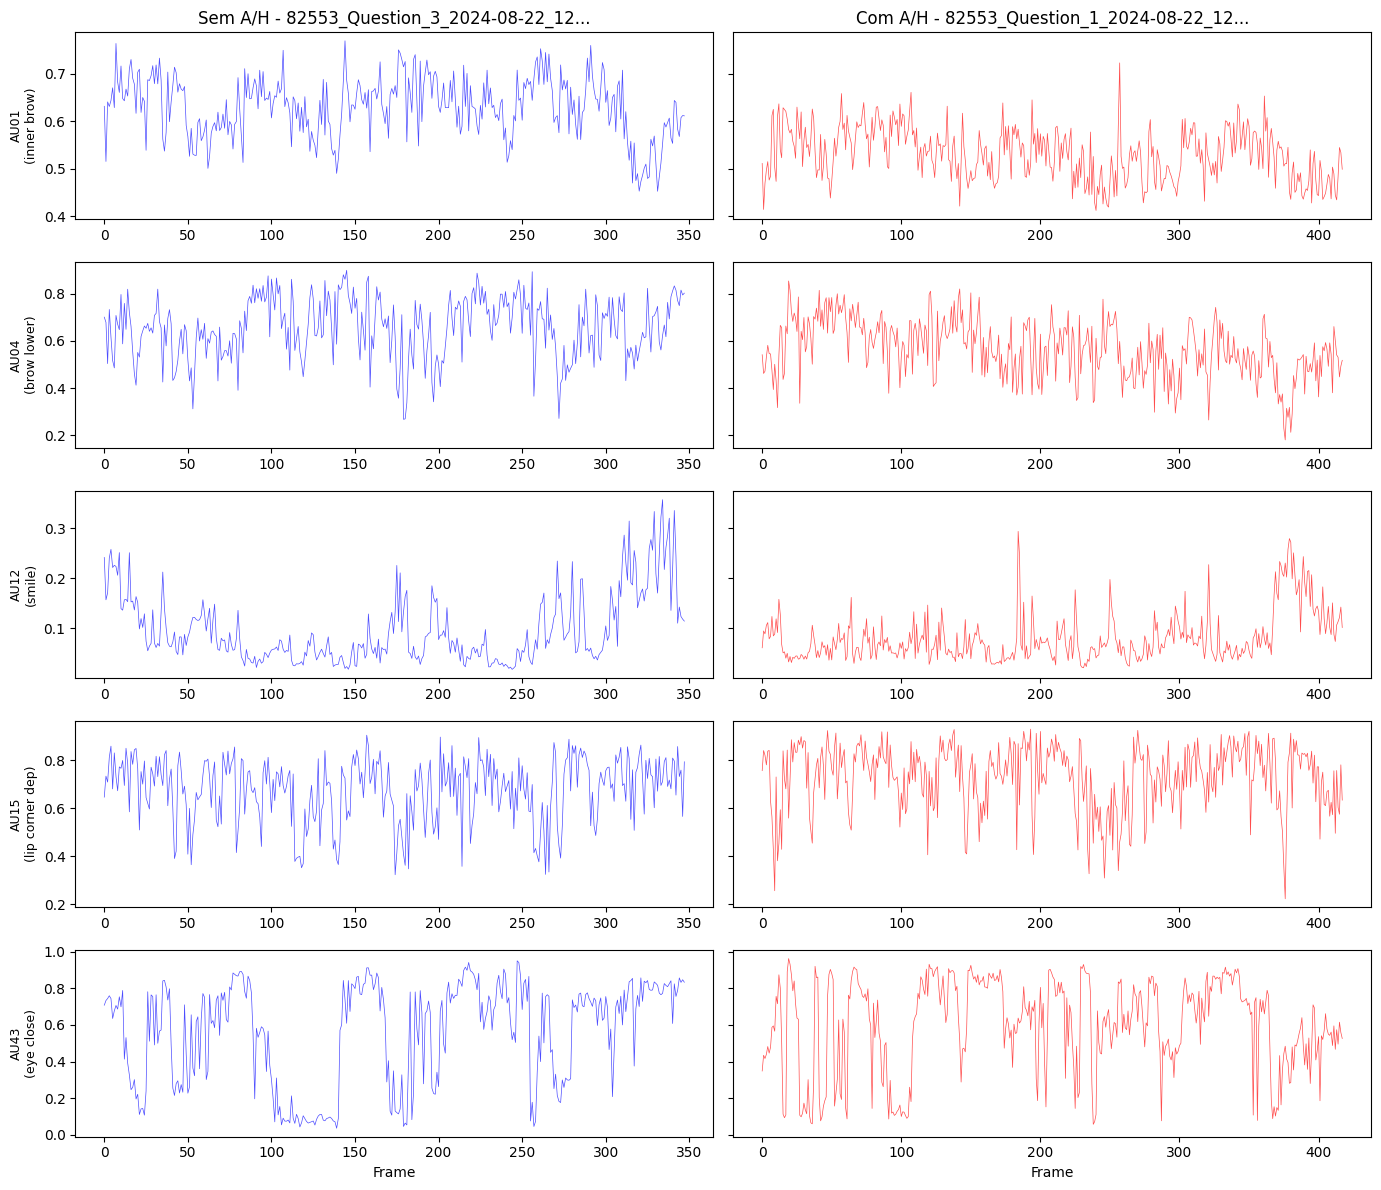

In [18]:
# Análise 3: Evolução temporal de AUs-chave num vídeo A/H vs não-A/H
# Pegar um vídeo A/H e um sem A/H do participante 82553
video_ah = None
video_no_ah = None

for video_name, aus in au_data['82553'].items():
    row = df[df['video-path'].str.contains(video_name.replace('.mp4', ''))]
    label = row['label'].values[0] if len(row) > 0 else 0
    if label == 1 and video_ah is None:
        video_ah = (video_name, aus)
    if label == 0 and video_no_ah is None:
        video_no_ah = (video_name, aus)

# AUs mais relevantes das cues: AU01(inner brow), AU04(brow lower), AU12(smile), AU15(lip depress), AU43(eye closure)
key_aus = [0, 2, 9, 11, 19]  # indices de AU01, AU04, AU12, AU15, AU43
key_au_names = ['AU01\n(inner brow)', 'AU04\n(brow lower)', 'AU12\n(smile)', 'AU15\n(lip corner dep)', 'AU43\n(eye close)']

fig, axes = plt.subplots(5, 2, figsize=(14, 12), sharey='row')

for i, (au_idx, au_name) in enumerate(zip(key_aus, key_au_names)):
    # Vídeo sem A/H
    axes[i, 0].plot(video_no_ah[1][:, au_idx], color='blue', alpha=0.7, linewidth=0.5)
    axes[i, 0].set_ylabel(au_name, fontsize=9)
    if i == 0:
        axes[i, 0].set_title(f'Sem A/H - {video_no_ah[0][:30]}...')

    # Vídeo com A/H
    axes[i, 1].plot(video_ah[1][:, au_idx], color='red', alpha=0.7, linewidth=0.5)
    if i == 0:
        axes[i, 1].set_title(f'Com A/H - {video_ah[0][:30]}...')

axes[-1, 0].set_xlabel('Frame')
axes[-1, 1].set_xlabel('Frame')
plt.tight_layout()
plt.show()